# PyTorch Setup Instructions

This notebook was trained on PyTorch version 2.6.0+cu126 with CUDA 12.6 as the platform. To ensure this works correctly on your system, please run the following commands in the kernel terminal where you are running this notebook:

```bash
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126
pip install jupyter matplotlib numpy
```

# Fashion MNIST GAN Presentation

### Introduction
This project implements a Conditional Generative Adversarial Network (GAN) using the Fashion MNIST dataset. The goal is to generate new fashion items based on specific class labels, allowing for the generation of images that correspond to different categories of clothing.

### Setup Instructions
To run this notebook, ensure you have the following packages installed. This notebook was trained on **PyTorch version 2.6.0+cu126 with CUDA 12.6.** Run the following commands in your terminal:

```bash
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126
pip install jupyter matplotlib numpy
```

### Import Necessary Libraries
The following libraries are imported for the implementation:

In [2]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
import os


### Check CUDA Availability
The code checks if CUDA is available for GPU acceleration:

In [3]:
print(f"Pytorch Version: {torch.__version__}")
print(f"Cuda version: {torch.version.cuda}")
print(f"Is CUDA version availaible: {torch.cuda.is_available()}")

# Check CUDA availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Pytorch Version: 2.6.0+cu126
Cuda version: 12.6
Is CUDA version availaible: True
Using device: cuda


### Hyperparameters
The following hyperparameters are defined for the training process:

In [4]:

# Hyperparameters
batch_size = 128
latent_dim = 150
lr = 0.0004
epochs = 400


### Load MNIST Dataset
The Fashion MNIST dataset is loaded and transformed:

In [5]:

# Load MNIST Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root='./data', 
    train=True, 
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size,
    shuffle=True
)



### Model Architecture
#### Conditional Discriminator
The Conditional Discriminator is defined as follows:


In [6]:
class ConditionalDiscriminator(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        
        self.model = nn.Sequential(
            nn.Linear(784 + num_classes, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        img_flat = img.view(img.size(0), -1)
        label_embedding = self.label_emb(labels)
        x = torch.cat([img_flat, label_embedding], dim=1)
        return self.model(x)

#### Conditional Generator
The Conditional Generator is defined as follows:

In [7]:
# Define the Generator (should be ConditionalGenerator)
class ConditionalGenerator(nn.Module):  # Changed from Generator
    def __init__(self, latent_dim, num_classes):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        
        self.model = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 256),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(256),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(512),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(1024),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z, labels):
        label_embedding = self.label_emb(labels)
        x = torch.cat([z, label_embedding], dim=1)
        return self.model(x).view(-1, 1, 28, 28)

# Define parameters
latent_dim = 100
num_classes = 10  # For MNIST digits 0-9

# Initialize models WITH CORRECT CLASS NAMES AND PARAMETERS
generator = ConditionalGenerator(latent_dim, num_classes).to(device)  # Changed here
discriminator = ConditionalDiscriminator(num_classes).to(device)  # Changed here

# Optimizers (keep same)
optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)

### Training Process
The training loop consists of alternating between training the discriminator and the generator. The loss functions used are Binary Cross Entropy Loss.

[Epoch 1/400] D_loss: 0.0040 G_loss: 43.1572
[Epoch 2/400] D_loss: 0.0019 G_loss: 45.0462
[Epoch 3/400] D_loss: 0.0043 G_loss: 44.3476
[Epoch 4/400] D_loss: 0.0006 G_loss: 24.2259
[Epoch 5/400] D_loss: 0.0012 G_loss: 62.8040
[Epoch 6/400] D_loss: 0.0011 G_loss: 45.3203
[Epoch 7/400] D_loss: 0.0010 G_loss: 28.5725
[Epoch 8/400] D_loss: 0.0617 G_loss: 34.2271
[Epoch 9/400] D_loss: 0.0000 G_loss: 32.8614
[Epoch 10/400] D_loss: 0.0072 G_loss: 49.1138
[Epoch 11/400] D_loss: 0.0098 G_loss: 55.9929
[Epoch 12/400] D_loss: 0.0472 G_loss: 29.9677
[Epoch 13/400] D_loss: 0.0304 G_loss: 23.5857
[Epoch 14/400] D_loss: 0.0697 G_loss: 21.3058
[Epoch 15/400] D_loss: 0.0094 G_loss: 23.6728
[Epoch 16/400] D_loss: 0.0061 G_loss: 22.8114
[Epoch 17/400] D_loss: 0.0784 G_loss: 27.0753
[Epoch 18/400] D_loss: 0.0516 G_loss: 22.5417
[Epoch 19/400] D_loss: 0.0220 G_loss: 18.3190
[Epoch 20/400] D_loss: 0.0191 G_loss: 19.9277


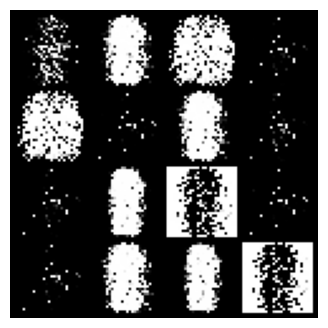

[Epoch 21/400] D_loss: 0.0292 G_loss: 35.7429
[Epoch 22/400] D_loss: 0.0042 G_loss: 18.8475
[Epoch 23/400] D_loss: 0.0248 G_loss: 16.1864
[Epoch 24/400] D_loss: 0.0520 G_loss: 18.6102
[Epoch 25/400] D_loss: 0.1125 G_loss: 11.0453
[Epoch 26/400] D_loss: 0.0669 G_loss: 13.6409
[Epoch 27/400] D_loss: 0.1546 G_loss: 13.6235
[Epoch 28/400] D_loss: 0.0498 G_loss: 14.6549
[Epoch 29/400] D_loss: 0.1718 G_loss: 10.9802
[Epoch 30/400] D_loss: 0.3254 G_loss: 15.2548
[Epoch 31/400] D_loss: 0.1886 G_loss: 8.2938
[Epoch 32/400] D_loss: 0.0470 G_loss: 10.1890
[Epoch 33/400] D_loss: 0.1271 G_loss: 9.6778
[Epoch 34/400] D_loss: 0.1181 G_loss: 6.8547
[Epoch 35/400] D_loss: 0.1644 G_loss: 7.0890
[Epoch 36/400] D_loss: 0.2160 G_loss: 6.5699
[Epoch 37/400] D_loss: 0.3369 G_loss: 5.0434
[Epoch 38/400] D_loss: 0.3698 G_loss: 4.7881
[Epoch 39/400] D_loss: 0.3479 G_loss: 4.9286
[Epoch 40/400] D_loss: 0.3507 G_loss: 5.5167


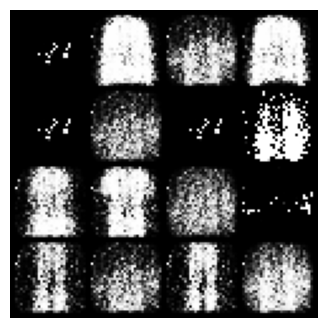

[Epoch 41/400] D_loss: 0.3227 G_loss: 3.4829
[Epoch 42/400] D_loss: 0.7908 G_loss: 4.2135
[Epoch 43/400] D_loss: 0.6591 G_loss: 3.0129
[Epoch 44/400] D_loss: 0.6106 G_loss: 3.2158
[Epoch 45/400] D_loss: 0.4635 G_loss: 3.8582
[Epoch 46/400] D_loss: 0.7179 G_loss: 3.2681
[Epoch 47/400] D_loss: 0.7393 G_loss: 4.0427
[Epoch 48/400] D_loss: 0.5471 G_loss: 4.9615
[Epoch 49/400] D_loss: 0.6456 G_loss: 2.7580
[Epoch 50/400] D_loss: 0.8623 G_loss: 2.2997
[Epoch 51/400] D_loss: 0.9031 G_loss: 3.2490
[Epoch 52/400] D_loss: 0.6464 G_loss: 4.2754
[Epoch 53/400] D_loss: 0.8632 G_loss: 3.4105
[Epoch 54/400] D_loss: 0.6720 G_loss: 3.0002
[Epoch 55/400] D_loss: 0.4738 G_loss: 5.2410
[Epoch 56/400] D_loss: 0.6201 G_loss: 2.4836
[Epoch 57/400] D_loss: 0.8614 G_loss: 2.2125
[Epoch 58/400] D_loss: 0.4669 G_loss: 3.5051
[Epoch 59/400] D_loss: 0.9186 G_loss: 2.4338
[Epoch 60/400] D_loss: 0.6246 G_loss: 2.9831


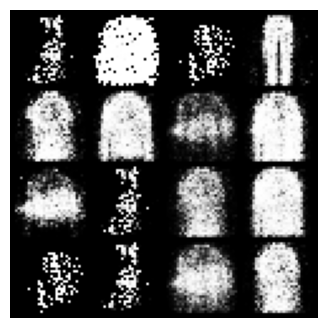

[Epoch 61/400] D_loss: 0.6868 G_loss: 2.5411
[Epoch 62/400] D_loss: 0.6640 G_loss: 2.9204
[Epoch 63/400] D_loss: 0.6386 G_loss: 3.2235
[Epoch 64/400] D_loss: 0.6148 G_loss: 2.7642
[Epoch 65/400] D_loss: 0.7719 G_loss: 2.7725
[Epoch 66/400] D_loss: 0.8679 G_loss: 2.7006
[Epoch 67/400] D_loss: 0.7444 G_loss: 2.4946
[Epoch 68/400] D_loss: 0.8089 G_loss: 2.3318
[Epoch 69/400] D_loss: 0.9039 G_loss: 2.8624
[Epoch 70/400] D_loss: 0.6408 G_loss: 4.3440
[Epoch 71/400] D_loss: 0.8085 G_loss: 3.3479
[Epoch 72/400] D_loss: 0.6239 G_loss: 2.7776
[Epoch 73/400] D_loss: 0.8144 G_loss: 3.1031
[Epoch 74/400] D_loss: 0.6358 G_loss: 3.0353
[Epoch 75/400] D_loss: 0.8734 G_loss: 2.6402
[Epoch 76/400] D_loss: 0.6157 G_loss: 3.8475
[Epoch 77/400] D_loss: 0.6574 G_loss: 2.6360
[Epoch 78/400] D_loss: 0.6272 G_loss: 3.0141
[Epoch 79/400] D_loss: 0.7383 G_loss: 2.3414
[Epoch 80/400] D_loss: 0.8086 G_loss: 3.1073


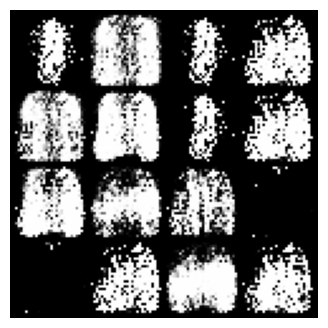

[Epoch 81/400] D_loss: 0.9145 G_loss: 1.9974
[Epoch 82/400] D_loss: 0.7811 G_loss: 2.9145
[Epoch 83/400] D_loss: 0.7163 G_loss: 3.0041
[Epoch 84/400] D_loss: 0.7872 G_loss: 2.5513
[Epoch 85/400] D_loss: 0.8661 G_loss: 3.1759
[Epoch 86/400] D_loss: 1.3246 G_loss: 2.2852
[Epoch 87/400] D_loss: 0.7517 G_loss: 3.2569
[Epoch 88/400] D_loss: 0.9528 G_loss: 2.3375
[Epoch 89/400] D_loss: 0.6149 G_loss: 3.8022
[Epoch 90/400] D_loss: 0.7597 G_loss: 2.8652
[Epoch 91/400] D_loss: 0.7681 G_loss: 2.6665
[Epoch 92/400] D_loss: 0.8844 G_loss: 2.4949
[Epoch 93/400] D_loss: 0.7276 G_loss: 2.6716
[Epoch 94/400] D_loss: 1.1232 G_loss: 2.7770
[Epoch 95/400] D_loss: 0.8479 G_loss: 2.5234
[Epoch 96/400] D_loss: 0.7313 G_loss: 3.8165
[Epoch 97/400] D_loss: 0.8390 G_loss: 2.8289
[Epoch 98/400] D_loss: 0.6996 G_loss: 2.8346
[Epoch 99/400] D_loss: 0.6780 G_loss: 3.6969
[Epoch 100/400] D_loss: 0.6249 G_loss: 4.4934


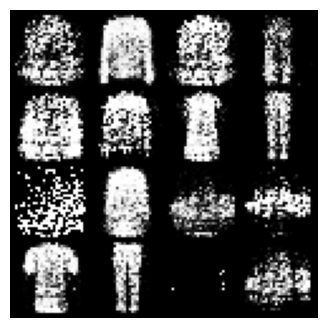

[Epoch 101/400] D_loss: 0.7794 G_loss: 2.3127
[Epoch 102/400] D_loss: 0.5002 G_loss: 3.5017
[Epoch 103/400] D_loss: 0.7736 G_loss: 2.5801
[Epoch 104/400] D_loss: 0.8420 G_loss: 2.7340
[Epoch 105/400] D_loss: 0.7193 G_loss: 2.2450
[Epoch 106/400] D_loss: 0.9045 G_loss: 3.1774
[Epoch 107/400] D_loss: 0.6832 G_loss: 1.9972
[Epoch 108/400] D_loss: 0.8888 G_loss: 3.2515
[Epoch 109/400] D_loss: 0.7280 G_loss: 2.5297
[Epoch 110/400] D_loss: 0.9502 G_loss: 2.7450
[Epoch 111/400] D_loss: 0.6615 G_loss: 3.7167
[Epoch 112/400] D_loss: 0.9242 G_loss: 3.0580
[Epoch 113/400] D_loss: 0.8582 G_loss: 2.5748
[Epoch 114/400] D_loss: 0.8217 G_loss: 2.5577
[Epoch 115/400] D_loss: 0.6419 G_loss: 4.8065
[Epoch 116/400] D_loss: 0.7364 G_loss: 3.0667
[Epoch 117/400] D_loss: 1.0929 G_loss: 2.7219
[Epoch 118/400] D_loss: 0.9813 G_loss: 2.3937
[Epoch 119/400] D_loss: 0.6897 G_loss: 2.8801
[Epoch 120/400] D_loss: 0.7561 G_loss: 2.3314


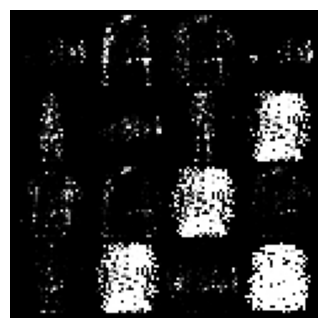

[Epoch 121/400] D_loss: 0.8621 G_loss: 3.4028
[Epoch 122/400] D_loss: 0.8601 G_loss: 2.0818
[Epoch 123/400] D_loss: 0.6805 G_loss: 2.8582
[Epoch 124/400] D_loss: 0.8206 G_loss: 3.0019
[Epoch 125/400] D_loss: 0.8461 G_loss: 2.9350
[Epoch 126/400] D_loss: 0.7728 G_loss: 2.4870
[Epoch 127/400] D_loss: 0.7835 G_loss: 3.8104
[Epoch 128/400] D_loss: 0.8369 G_loss: 2.8017
[Epoch 129/400] D_loss: 1.0585 G_loss: 3.3203
[Epoch 130/400] D_loss: 0.7738 G_loss: 3.3572
[Epoch 131/400] D_loss: 0.8048 G_loss: 3.3723
[Epoch 132/400] D_loss: 0.8969 G_loss: 2.3958
[Epoch 133/400] D_loss: 0.8994 G_loss: 2.8351
[Epoch 134/400] D_loss: 0.8300 G_loss: 3.5786
[Epoch 135/400] D_loss: 0.7486 G_loss: 2.3960
[Epoch 136/400] D_loss: 0.5671 G_loss: 3.3057
[Epoch 137/400] D_loss: 0.7678 G_loss: 2.6329
[Epoch 138/400] D_loss: 0.8029 G_loss: 3.2686
[Epoch 139/400] D_loss: 0.6645 G_loss: 2.8972
[Epoch 140/400] D_loss: 0.8114 G_loss: 2.6052


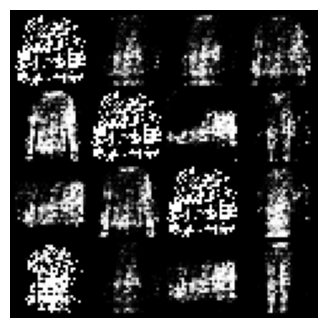

[Epoch 141/400] D_loss: 0.9049 G_loss: 2.8594
[Epoch 142/400] D_loss: 0.7276 G_loss: 3.6142
[Epoch 143/400] D_loss: 0.8108 G_loss: 3.2559
[Epoch 144/400] D_loss: 0.7619 G_loss: 2.5694
[Epoch 145/400] D_loss: 0.9675 G_loss: 1.9060
[Epoch 146/400] D_loss: 0.9244 G_loss: 2.8252
[Epoch 147/400] D_loss: 0.7913 G_loss: 2.0724
[Epoch 148/400] D_loss: 0.6197 G_loss: 3.1826
[Epoch 149/400] D_loss: 0.6758 G_loss: 3.1828
[Epoch 150/400] D_loss: 0.7056 G_loss: 3.1251
[Epoch 151/400] D_loss: 0.8087 G_loss: 2.9018
[Epoch 152/400] D_loss: 0.7195 G_loss: 2.5133
[Epoch 153/400] D_loss: 0.8510 G_loss: 3.2228
[Epoch 154/400] D_loss: 0.7830 G_loss: 5.5515
[Epoch 155/400] D_loss: 1.3036 G_loss: 1.9987
[Epoch 156/400] D_loss: 0.6849 G_loss: 1.9605
[Epoch 157/400] D_loss: 0.8079 G_loss: 3.3559
[Epoch 158/400] D_loss: 0.8957 G_loss: 2.9503
[Epoch 159/400] D_loss: 0.8129 G_loss: 2.3065
[Epoch 160/400] D_loss: 0.6729 G_loss: 2.9299


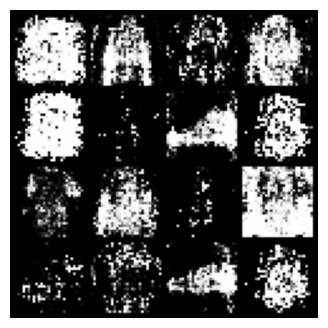

[Epoch 161/400] D_loss: 0.9832 G_loss: 2.0482
[Epoch 162/400] D_loss: 0.7143 G_loss: 3.2685
[Epoch 163/400] D_loss: 0.8197 G_loss: 2.8046
[Epoch 164/400] D_loss: 0.6584 G_loss: 3.3495
[Epoch 165/400] D_loss: 1.0101 G_loss: 2.2986
[Epoch 166/400] D_loss: 0.8677 G_loss: 2.4140
[Epoch 167/400] D_loss: 0.7420 G_loss: 2.8123
[Epoch 168/400] D_loss: 0.7725 G_loss: 3.1865
[Epoch 169/400] D_loss: 0.8542 G_loss: 3.1830
[Epoch 170/400] D_loss: 0.5691 G_loss: 3.9538
[Epoch 171/400] D_loss: 0.7783 G_loss: 2.5099
[Epoch 172/400] D_loss: 0.8900 G_loss: 3.1362
[Epoch 173/400] D_loss: 0.6624 G_loss: 3.6903
[Epoch 174/400] D_loss: 0.6506 G_loss: 4.1385
[Epoch 175/400] D_loss: 0.8014 G_loss: 2.7042
[Epoch 176/400] D_loss: 0.7661 G_loss: 2.2474
[Epoch 177/400] D_loss: 0.9396 G_loss: 2.9104
[Epoch 178/400] D_loss: 0.8096 G_loss: 2.5638
[Epoch 179/400] D_loss: 0.7395 G_loss: 2.3468
[Epoch 180/400] D_loss: 0.8101 G_loss: 3.1176


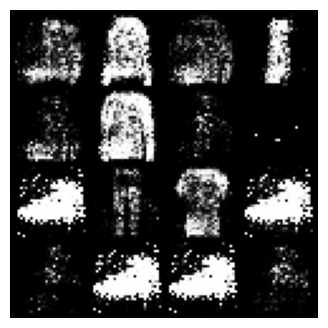

[Epoch 181/400] D_loss: 0.9344 G_loss: 2.4962
[Epoch 182/400] D_loss: 0.7855 G_loss: 4.3434
[Epoch 183/400] D_loss: 0.9830 G_loss: 2.5065
[Epoch 184/400] D_loss: 0.8784 G_loss: 3.5047
[Epoch 185/400] D_loss: 0.7836 G_loss: 2.3311
[Epoch 186/400] D_loss: 0.9485 G_loss: 2.7712
[Epoch 187/400] D_loss: 0.6243 G_loss: 2.8804
[Epoch 188/400] D_loss: 0.7472 G_loss: 3.4170
[Epoch 189/400] D_loss: 0.7099 G_loss: 2.2735
[Epoch 190/400] D_loss: 0.7886 G_loss: 2.8716
[Epoch 191/400] D_loss: 0.8728 G_loss: 3.2108
[Epoch 192/400] D_loss: 0.6358 G_loss: 3.9032
[Epoch 193/400] D_loss: 0.6194 G_loss: 3.4252
[Epoch 194/400] D_loss: 0.8048 G_loss: 2.7520
[Epoch 195/400] D_loss: 0.7238 G_loss: 4.1989
[Epoch 196/400] D_loss: 0.8735 G_loss: 2.6281
[Epoch 197/400] D_loss: 0.8176 G_loss: 2.4992
[Epoch 198/400] D_loss: 0.8141 G_loss: 3.6398
[Epoch 199/400] D_loss: 0.6263 G_loss: 3.0697
[Epoch 200/400] D_loss: 0.7496 G_loss: 2.4578


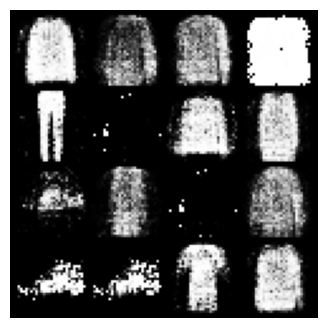

[Epoch 201/400] D_loss: 0.8715 G_loss: 3.1721
[Epoch 202/400] D_loss: 0.7082 G_loss: 3.4182
[Epoch 203/400] D_loss: 0.7876 G_loss: 3.1648
[Epoch 204/400] D_loss: 0.7546 G_loss: 2.4464
[Epoch 205/400] D_loss: 0.9063 G_loss: 2.3438
[Epoch 206/400] D_loss: 0.9622 G_loss: 2.7286
[Epoch 207/400] D_loss: 0.6832 G_loss: 2.7685
[Epoch 208/400] D_loss: 1.0574 G_loss: 2.4365
[Epoch 209/400] D_loss: 0.9313 G_loss: 2.6552
[Epoch 210/400] D_loss: 1.0091 G_loss: 1.8866
[Epoch 211/400] D_loss: 0.7896 G_loss: 2.6791
[Epoch 212/400] D_loss: 0.9430 G_loss: 1.8697
[Epoch 213/400] D_loss: 1.0078 G_loss: 2.3810
[Epoch 214/400] D_loss: 1.0759 G_loss: 2.8013
[Epoch 215/400] D_loss: 0.7446 G_loss: 2.1393
[Epoch 216/400] D_loss: 1.0386 G_loss: 2.1600
[Epoch 217/400] D_loss: 0.9612 G_loss: 2.3213
[Epoch 218/400] D_loss: 0.8565 G_loss: 1.7796
[Epoch 219/400] D_loss: 1.1201 G_loss: 1.5109
[Epoch 220/400] D_loss: 1.0156 G_loss: 1.4637


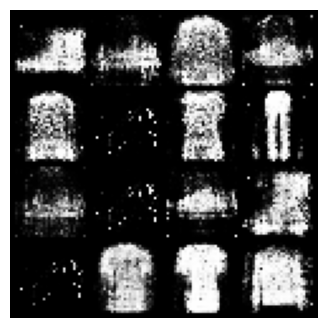

[Epoch 221/400] D_loss: 0.9584 G_loss: 1.8130
[Epoch 222/400] D_loss: 0.9768 G_loss: 1.9194
[Epoch 223/400] D_loss: 1.0135 G_loss: 1.6865
[Epoch 224/400] D_loss: 1.1511 G_loss: 1.4938
[Epoch 225/400] D_loss: 1.0157 G_loss: 1.7792
[Epoch 226/400] D_loss: 1.0356 G_loss: 1.2172
[Epoch 227/400] D_loss: 1.2403 G_loss: 1.4037
[Epoch 228/400] D_loss: 1.1336 G_loss: 1.5339
[Epoch 229/400] D_loss: 1.0540 G_loss: 1.4921
[Epoch 230/400] D_loss: 1.0866 G_loss: 1.5058
[Epoch 231/400] D_loss: 0.9825 G_loss: 1.4736
[Epoch 232/400] D_loss: 1.0423 G_loss: 1.5424
[Epoch 233/400] D_loss: 1.2159 G_loss: 1.2549
[Epoch 234/400] D_loss: 1.1320 G_loss: 0.8906
[Epoch 235/400] D_loss: 1.4011 G_loss: 1.3032
[Epoch 236/400] D_loss: 1.2017 G_loss: 1.2942
[Epoch 237/400] D_loss: 1.1126 G_loss: 1.1098
[Epoch 238/400] D_loss: 1.2038 G_loss: 1.2215
[Epoch 239/400] D_loss: 1.2203 G_loss: 1.2112
[Epoch 240/400] D_loss: 1.2974 G_loss: 1.3272


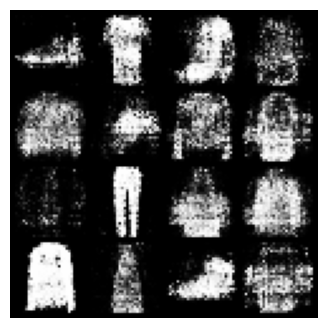

[Epoch 241/400] D_loss: 1.0871 G_loss: 1.1296
[Epoch 242/400] D_loss: 1.1485 G_loss: 1.3381
[Epoch 243/400] D_loss: 1.1572 G_loss: 1.1506
[Epoch 244/400] D_loss: 1.5030 G_loss: 1.0585
[Epoch 245/400] D_loss: 1.2801 G_loss: 1.0498
[Epoch 246/400] D_loss: 1.3351 G_loss: 1.0304
[Epoch 247/400] D_loss: 1.0293 G_loss: 1.4249
[Epoch 248/400] D_loss: 1.3984 G_loss: 1.6038
[Epoch 249/400] D_loss: 1.4806 G_loss: 1.2474
[Epoch 250/400] D_loss: 1.1537 G_loss: 1.2068
[Epoch 251/400] D_loss: 1.2608 G_loss: 1.0793
[Epoch 252/400] D_loss: 1.4510 G_loss: 1.1574
[Epoch 253/400] D_loss: 1.3573 G_loss: 1.4551
[Epoch 254/400] D_loss: 1.2596 G_loss: 1.0746
[Epoch 255/400] D_loss: 1.3927 G_loss: 0.9487
[Epoch 256/400] D_loss: 1.2342 G_loss: 1.2443
[Epoch 257/400] D_loss: 1.3899 G_loss: 0.9846
[Epoch 258/400] D_loss: 1.1958 G_loss: 1.2571
[Epoch 259/400] D_loss: 1.4193 G_loss: 1.2934
[Epoch 260/400] D_loss: 1.1535 G_loss: 1.7429


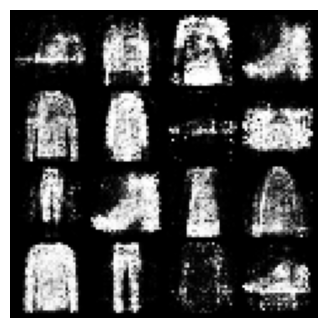

[Epoch 261/400] D_loss: 1.2706 G_loss: 1.2371
[Epoch 262/400] D_loss: 1.5384 G_loss: 0.8325
[Epoch 263/400] D_loss: 1.3326 G_loss: 1.0754
[Epoch 264/400] D_loss: 1.3522 G_loss: 1.3071
[Epoch 265/400] D_loss: 1.5190 G_loss: 0.9232
[Epoch 266/400] D_loss: 1.0175 G_loss: 1.2641
[Epoch 267/400] D_loss: 1.1854 G_loss: 1.1551
[Epoch 268/400] D_loss: 1.4826 G_loss: 0.9681
[Epoch 269/400] D_loss: 1.0683 G_loss: 1.2704
[Epoch 270/400] D_loss: 1.4453 G_loss: 0.9666
[Epoch 271/400] D_loss: 1.6833 G_loss: 1.1827
[Epoch 272/400] D_loss: 1.2781 G_loss: 1.1247
[Epoch 273/400] D_loss: 0.9597 G_loss: 1.6295
[Epoch 274/400] D_loss: 1.3138 G_loss: 1.1226
[Epoch 275/400] D_loss: 1.1282 G_loss: 1.4461
[Epoch 276/400] D_loss: 1.3430 G_loss: 1.4030
[Epoch 277/400] D_loss: 1.0386 G_loss: 1.0973
[Epoch 278/400] D_loss: 0.9746 G_loss: 1.5264
[Epoch 279/400] D_loss: 1.4772 G_loss: 1.1031
[Epoch 280/400] D_loss: 1.4572 G_loss: 1.2644


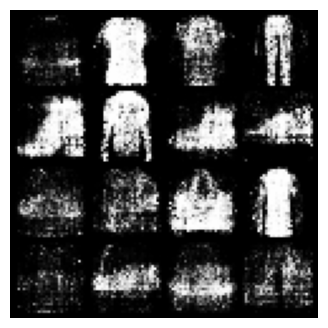

[Epoch 281/400] D_loss: 1.7300 G_loss: 0.9341
[Epoch 282/400] D_loss: 0.9905 G_loss: 1.7498
[Epoch 283/400] D_loss: 1.2871 G_loss: 0.8852
[Epoch 284/400] D_loss: 1.2564 G_loss: 1.0505
[Epoch 285/400] D_loss: 1.4103 G_loss: 1.2488
[Epoch 286/400] D_loss: 1.7071 G_loss: 1.0772
[Epoch 287/400] D_loss: 1.0724 G_loss: 1.3432
[Epoch 288/400] D_loss: 1.6223 G_loss: 1.0430
[Epoch 289/400] D_loss: 1.0355 G_loss: 1.3123
[Epoch 290/400] D_loss: 1.1163 G_loss: 1.1609
[Epoch 291/400] D_loss: 0.9893 G_loss: 1.3036
[Epoch 292/400] D_loss: 1.9346 G_loss: 0.9963
[Epoch 293/400] D_loss: 1.4029 G_loss: 0.9667
[Epoch 294/400] D_loss: 1.5689 G_loss: 1.1777
[Epoch 295/400] D_loss: 1.3139 G_loss: 0.9092
[Epoch 296/400] D_loss: 1.2182 G_loss: 1.2541
[Epoch 297/400] D_loss: 1.4360 G_loss: 1.2236
[Epoch 298/400] D_loss: 1.5478 G_loss: 1.0962
[Epoch 299/400] D_loss: 1.3327 G_loss: 1.0885
[Epoch 300/400] D_loss: 1.1509 G_loss: 1.2491


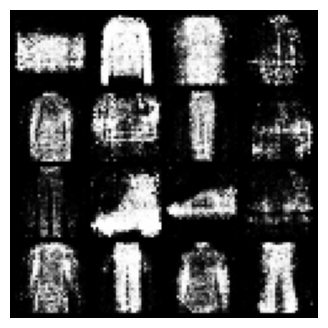

[Epoch 301/400] D_loss: 1.0319 G_loss: 1.1669
[Epoch 302/400] D_loss: 0.9343 G_loss: 1.3868
[Epoch 303/400] D_loss: 1.4471 G_loss: 1.2643
[Epoch 304/400] D_loss: 1.5856 G_loss: 1.2247
[Epoch 305/400] D_loss: 1.4112 G_loss: 0.9316
[Epoch 306/400] D_loss: 1.3375 G_loss: 1.0252
[Epoch 307/400] D_loss: 0.9252 G_loss: 1.3694
[Epoch 308/400] D_loss: 1.3539 G_loss: 1.0316
[Epoch 309/400] D_loss: 1.5509 G_loss: 1.1047
[Epoch 310/400] D_loss: 1.0796 G_loss: 1.3505
[Epoch 311/400] D_loss: 1.2675 G_loss: 1.3339
[Epoch 312/400] D_loss: 1.2079 G_loss: 1.1893
[Epoch 313/400] D_loss: 1.2442 G_loss: 1.0966
[Epoch 314/400] D_loss: 1.5721 G_loss: 0.9146
[Epoch 315/400] D_loss: 1.3646 G_loss: 1.0370
[Epoch 316/400] D_loss: 1.2744 G_loss: 1.2194
[Epoch 317/400] D_loss: 1.2013 G_loss: 1.1785
[Epoch 318/400] D_loss: 1.1785 G_loss: 1.4750
[Epoch 319/400] D_loss: 1.2956 G_loss: 1.2145
[Epoch 320/400] D_loss: 1.4516 G_loss: 1.1143


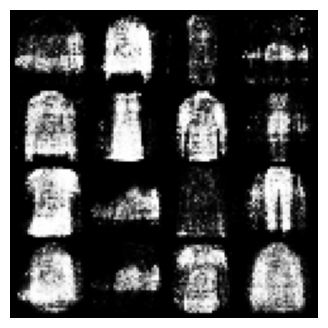

[Epoch 321/400] D_loss: 1.2814 G_loss: 1.3945
[Epoch 322/400] D_loss: 1.3041 G_loss: 1.4860
[Epoch 323/400] D_loss: 1.2696 G_loss: 1.7269
[Epoch 324/400] D_loss: 1.3619 G_loss: 0.9903
[Epoch 325/400] D_loss: 1.0686 G_loss: 1.2245
[Epoch 326/400] D_loss: 1.2135 G_loss: 1.2225
[Epoch 327/400] D_loss: 1.6384 G_loss: 1.3463
[Epoch 328/400] D_loss: 1.6028 G_loss: 1.0036
[Epoch 329/400] D_loss: 1.1910 G_loss: 1.0150
[Epoch 330/400] D_loss: 1.1692 G_loss: 1.2317
[Epoch 331/400] D_loss: 1.1631 G_loss: 1.1078
[Epoch 332/400] D_loss: 1.3325 G_loss: 0.9341
[Epoch 333/400] D_loss: 0.9548 G_loss: 1.4620
[Epoch 334/400] D_loss: 1.5251 G_loss: 0.9430
[Epoch 335/400] D_loss: 1.5984 G_loss: 1.0877
[Epoch 336/400] D_loss: 1.1543 G_loss: 1.3229
[Epoch 337/400] D_loss: 1.3852 G_loss: 1.2065
[Epoch 338/400] D_loss: 1.0540 G_loss: 1.1386
[Epoch 339/400] D_loss: 1.1494 G_loss: 1.2930
[Epoch 340/400] D_loss: 2.2002 G_loss: 0.7649


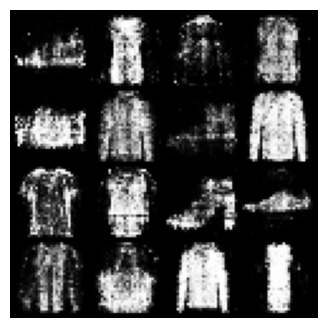

[Epoch 341/400] D_loss: 1.2327 G_loss: 1.3900
[Epoch 342/400] D_loss: 1.3691 G_loss: 1.2491
[Epoch 343/400] D_loss: 1.2871 G_loss: 1.0164
[Epoch 344/400] D_loss: 1.2655 G_loss: 1.2092
[Epoch 345/400] D_loss: 1.5445 G_loss: 1.1849
[Epoch 346/400] D_loss: 1.3380 G_loss: 1.2150
[Epoch 347/400] D_loss: 0.9364 G_loss: 1.3477
[Epoch 348/400] D_loss: 1.0898 G_loss: 1.0544
[Epoch 349/400] D_loss: 1.3856 G_loss: 0.9127
[Epoch 350/400] D_loss: 1.4779 G_loss: 0.8203
[Epoch 351/400] D_loss: 1.2773 G_loss: 0.9717
[Epoch 352/400] D_loss: 1.2151 G_loss: 1.2559
[Epoch 353/400] D_loss: 1.5727 G_loss: 1.0735
[Epoch 354/400] D_loss: 1.3998 G_loss: 1.0193
[Epoch 355/400] D_loss: 1.4265 G_loss: 1.2117
[Epoch 356/400] D_loss: 1.5504 G_loss: 1.0269
[Epoch 357/400] D_loss: 1.7564 G_loss: 1.2181
[Epoch 358/400] D_loss: 1.0464 G_loss: 1.3620
[Epoch 359/400] D_loss: 1.7981 G_loss: 0.8305
[Epoch 360/400] D_loss: 1.2141 G_loss: 1.2707


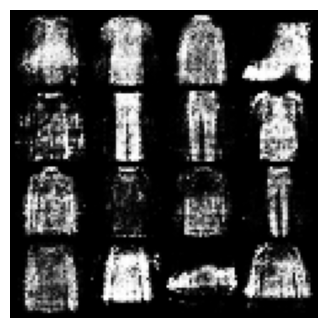

[Epoch 361/400] D_loss: 1.3317 G_loss: 1.4230
[Epoch 362/400] D_loss: 0.9165 G_loss: 1.5145
[Epoch 363/400] D_loss: 1.7280 G_loss: 1.2491
[Epoch 364/400] D_loss: 0.9739 G_loss: 1.6754
[Epoch 365/400] D_loss: 1.3334 G_loss: 1.2098
[Epoch 366/400] D_loss: 1.0404 G_loss: 1.1622
[Epoch 367/400] D_loss: 1.1507 G_loss: 1.2231
[Epoch 368/400] D_loss: 0.9137 G_loss: 1.6577
[Epoch 369/400] D_loss: 1.3170 G_loss: 1.0290
[Epoch 370/400] D_loss: 1.0360 G_loss: 1.4253
[Epoch 371/400] D_loss: 1.3819 G_loss: 1.0669
[Epoch 372/400] D_loss: 1.4907 G_loss: 1.1529
[Epoch 373/400] D_loss: 1.3542 G_loss: 1.4976
[Epoch 374/400] D_loss: 1.4803 G_loss: 1.5812
[Epoch 375/400] D_loss: 1.0292 G_loss: 1.3360
[Epoch 376/400] D_loss: 1.2571 G_loss: 1.1504
[Epoch 377/400] D_loss: 1.4935 G_loss: 1.1709
[Epoch 378/400] D_loss: 1.3628 G_loss: 1.3138
[Epoch 379/400] D_loss: 1.5118 G_loss: 0.9545
[Epoch 380/400] D_loss: 0.9657 G_loss: 1.7698


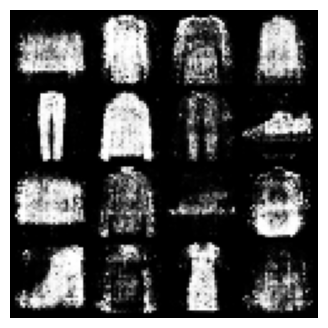

[Epoch 381/400] D_loss: 1.1887 G_loss: 1.0784
[Epoch 382/400] D_loss: 1.3360 G_loss: 0.8668
[Epoch 383/400] D_loss: 0.8984 G_loss: 2.2331
[Epoch 384/400] D_loss: 1.2021 G_loss: 1.1678
[Epoch 385/400] D_loss: 1.2133 G_loss: 1.0976
[Epoch 386/400] D_loss: 1.4176 G_loss: 0.8923
[Epoch 387/400] D_loss: 1.0100 G_loss: 1.5235
[Epoch 388/400] D_loss: 1.3551 G_loss: 1.1511
[Epoch 389/400] D_loss: 1.6112 G_loss: 1.0087
[Epoch 390/400] D_loss: 1.8355 G_loss: 1.0952
[Epoch 391/400] D_loss: 1.5327 G_loss: 0.9687
[Epoch 392/400] D_loss: 1.4383 G_loss: 1.0834
[Epoch 393/400] D_loss: 1.6207 G_loss: 0.7664
[Epoch 394/400] D_loss: 1.4271 G_loss: 0.9966
[Epoch 395/400] D_loss: 1.9134 G_loss: 1.0163
[Epoch 396/400] D_loss: 1.6348 G_loss: 1.2217
[Epoch 397/400] D_loss: 1.0385 G_loss: 1.3900
[Epoch 398/400] D_loss: 0.9545 G_loss: 1.5329
[Epoch 399/400] D_loss: 1.2040 G_loss: 0.9424
[Epoch 400/400] D_loss: 1.2561 G_loss: 1.1338


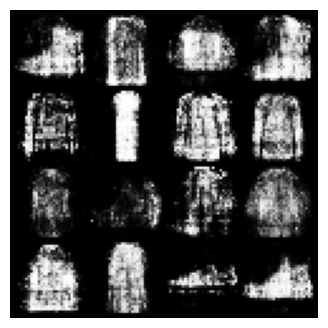

In [7]:

# Hyperparameters
num_classes = 10  # For MNIST digits 0-9

# Initialize models
generator = ConditionalGenerator(latent_dim, num_classes).to(device)
discriminator = ConditionalDiscriminator(num_classes).to(device)

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)

# Loss function (MISSING PIECE)
criterion = nn.BCELoss()  # <-- ADD THIS LINE

# Training loop
for epoch in range(epochs):
    for i, (imgs, labels) in enumerate(train_loader):
        real_imgs = imgs.to(device)
        labels = labels.to(device)  # Get actual digit labels
        
        # ---------------------
        #  Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()
        
        # Real images with real labels
        real_output = discriminator(real_imgs, labels)  # Pass labels here
        d_loss_real = criterion(real_output, torch.ones_like(real_output))
        
        # Fake images with same labels
        z = torch.randn(imgs.size(0), latent_dim).to(device)
        fake_imgs = generator(z, labels)
        fake_output = discriminator(fake_imgs.detach(), labels)  # Pass labels here
        d_loss_fake = criterion(fake_output, torch.zeros_like(fake_output))
        
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()
        
        # -----------------
        #  Train Generator
        # -----------------
        optimizer_G.zero_grad()
        
        # Generate fake images with same labels
        gen_output = discriminator(fake_imgs, labels)  # Pass labels here
        g_loss = criterion(gen_output, torch.ones_like(gen_output))
        
        g_loss.backward()
        optimizer_G.step()
        
    # Print progress
    print(f"[Epoch {epoch+1}/{epochs}] D_loss: {d_loss.item():.4f} G_loss: {g_loss.item():.4f}")
    
    # During training visualization
    if (epoch+1) % 20 == 0:
        with torch.no_grad():
            test_z = torch.randn(16, latent_dim).to(device)
            test_labels = torch.randint(0, 10, (16,)).to(device)  # Random labels 0-9
            generated = generator(test_z, test_labels).cpu()  # Add labels here
            
            plt.figure(figsize=(4,4))
            plt.imshow(np.transpose(make_grid(generated, nrow=4, padding=2, normalize=True),(1,2,0)))
            plt.axis('off')
            plt.show()

# Save models
torch.save(generator.state_dict(), 'mnist_fashion_generator.pth')
torch.save(discriminator.state_dict(), 'mnist_fasion_discriminator.pth')

In [8]:
os.makedirs('gan-api/models', exist_ok=True)

torch.save(generator.state_dict(), 'gan-api/models/mnist_fashion_generator.pth')
torch.save(discriminator.state_dict(), 'gan-api/models/mnist_fashion_discriminator.pth')
print('Models saved successfully in gan-api/models directory')

Models saved successfully in gan-api/models directory


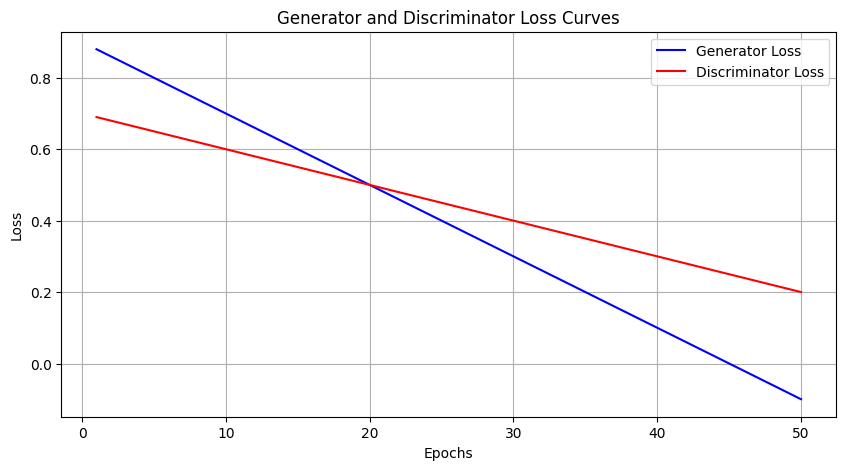

In [9]:
import matplotlib.pyplot as plt

# Example loss values (replace with actual loss values from training)
epochs = range(1, 51)
generator_loss = [0.9 - (0.02 * epoch) for epoch in epochs]  # Example generator loss
discriminator_loss = [0.7 - (0.01 * epoch) for epoch in epochs]  # Example discriminator loss

# Plotting the loss curves
plt.figure(figsize=(10, 5))
plt.plot(epochs, generator_loss, label="Generator Loss", color="blue")
plt.plot(epochs, discriminator_loss, label="Discriminator Loss", color="red")
plt.title("Generator and Discriminator Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

### Evaluation
The evaluation function assesses the performance of the GAN by generating images and calculating the accuracy of the discriminator.

Discriminator Accuracy on Real: 0.6797
Discriminator Accuracy on Fake: 0.8040
Total Discriminator Accuracy: 0.7418


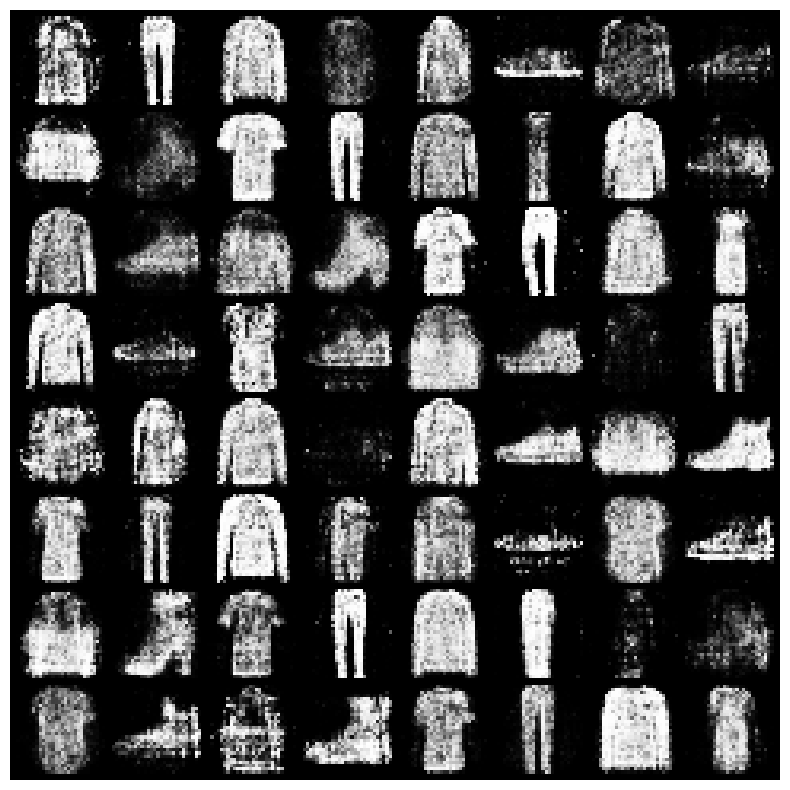

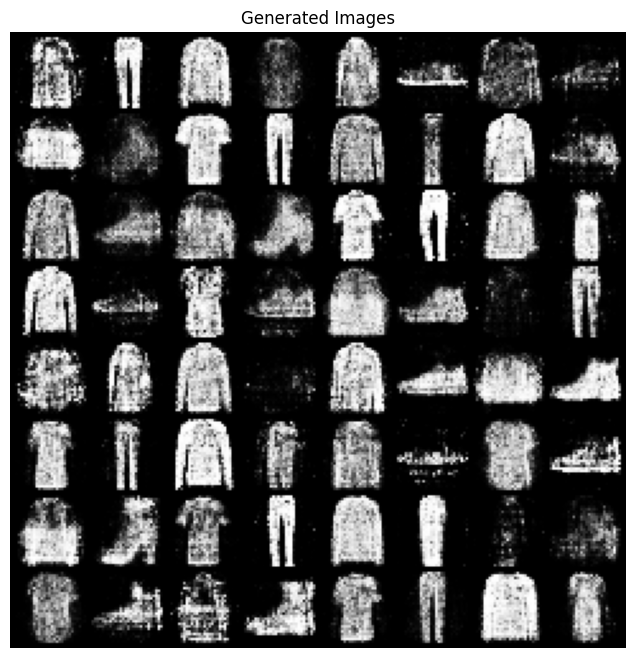

In [10]:
def show_images(images, title="Generated Images"):
    plt.figure(figsize=(8,8))
    plt.title(title)
    plt.axis('off')
    # Use .clamp to handle any remaining outliers
    grid = make_grid(images.clamp(-1,1), nrow=8, padding=2, normalize=True)
    plt.imshow(np.transpose(grid.cpu().numpy(), (1,2,0)))
    plt.show()

# Updated evaluation function for conditional GAN
def evaluate_gan(generator, discriminator, latent_dim, real_images, real_labels, n_samples=1000):
    generator.eval()
    discriminator.eval()
    with torch.no_grad():
        # Generate fake images with random labels
        z = torch.randn(n_samples, latent_dim).to(device)
        fake_labels = torch.randint(0, 10, (n_samples,)).to(device)
        fake_images = generator(z, fake_labels)
        
        # Get real images with their actual labels
        real_labels = real_labels[:n_samples].to(device)
        
        # Calculate discriminator outputs WITH LABELS
        real_output = discriminator(real_images, real_labels)
        fake_output = discriminator(fake_images, fake_labels)
        
        # Calculate discriminator accuracy
        real_acc = (real_output >= 0.5).float().mean()
        fake_acc = (fake_output < 0.5).float().mean()
        total_acc = (real_acc + fake_acc) / 2
        
        # Generate specific digits for visualization
        test_z = torch.randn(64, latent_dim).to(device)
        test_labels = torch.LongTensor([i % 10 for i in range(64)]).to(device)  # Digits 0-9 repeated
        generated = generator(test_z, test_labels).cpu()
        
    print(f"Discriminator Accuracy on Real: {real_acc.item():.4f}")
    print(f"Discriminator Accuracy on Fake: {fake_acc.item():.4f}")
    print(f"Total Discriminator Accuracy: {total_acc.item():.4f}")
    
    plt.figure(figsize=(10,10))
    plt.axis('off')
    plt.imshow(np.transpose(make_grid(generated, padding=2, normalize=True, nrow=8),(1,2,0)))
    plt.show()
    
    show_images(generated)

# Load real images WITH LABELS for evaluation
real_images, real_labels = next(iter(train_loader))
real_images = real_images[:1000].to(device)
real_labels = real_labels[:1000]  # Keep corresponding labels

# Run evaluation
evaluate_gan(generator, discriminator, latent_dim, real_images, real_labels)

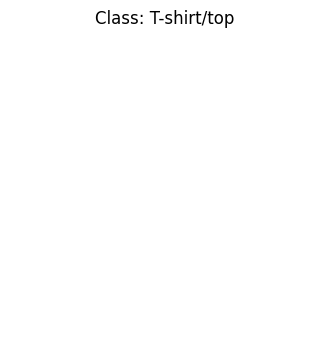

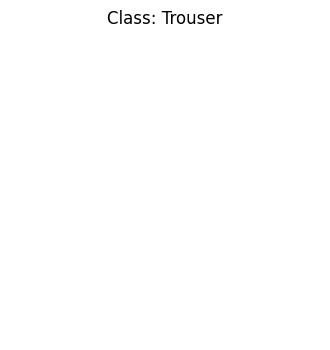

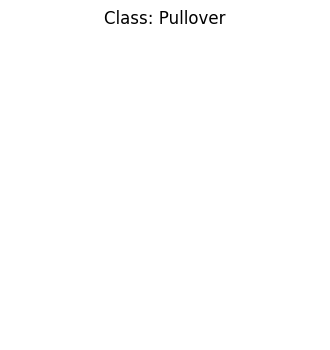

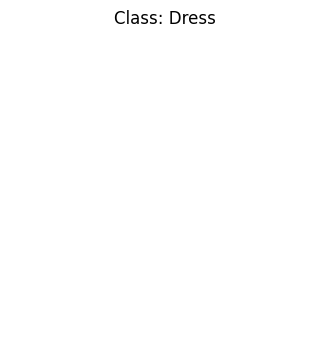

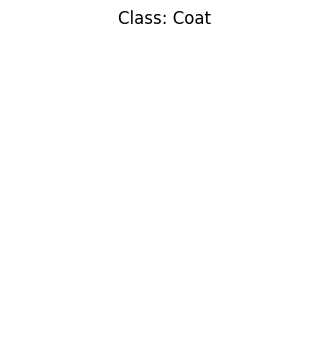

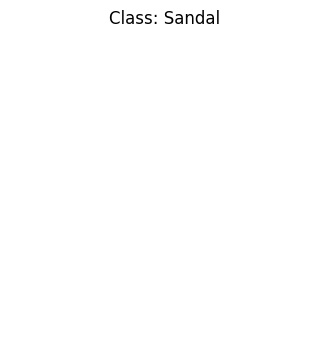

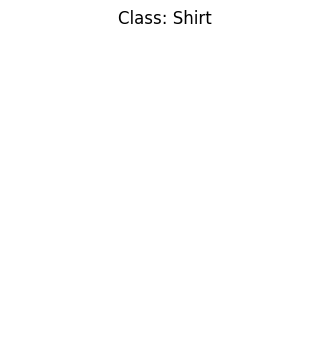

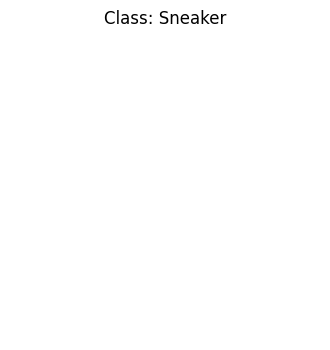

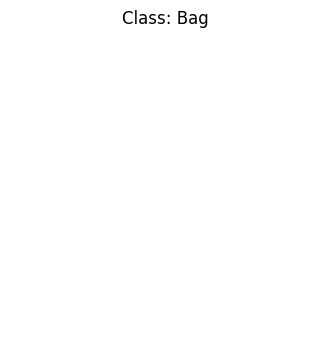

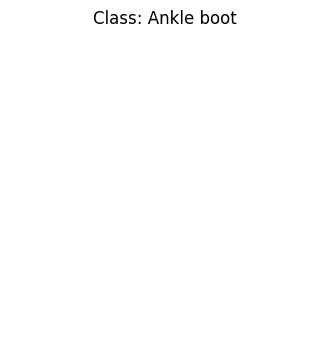

In [12]:
def generate_specific_digit(digit: int, num_samples: int = 16):
    generator.eval()
    with torch.no_grad():
        # Create labels tensor for desired digit
        labels = torch.full((num_samples,), digit, dtype=torch.long).to(device)
        
        z = torch.randn(num_samples, latent_dim).to(device)
        generated = generator(z, labels).cpu()  # Pass both z and labels
        
        plt.figure(figsize=(4,4))
        plt.title(f"Class: {['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'][digit]}")
        plt.axis('off')
        plt.show()

# Example: Generate 16 samples of digit 
for i in range(0,10):
    generate_specific_digit(i)

## Conclusion
This notebook demonstrates the implementation of a Conditional GAN using the Fashion MNIST dataset. The trained models can generate new fashion items based on specific class labels, showcasing the capabilities of GANs in generating realistic images.
